Script générant un attaque adverse simple : rotation. On test soit :

- Tout les angles pour toutes les images pour obtenir une accuracy moyenne du réseaux sur un data set en fonction de l'angle
- Tout les angle pour chaque image pour un label donné pour obtenir les angles maximisant ou minimisant la prediction d'un réseau sur ce label

--- TODO : ---

> Simplifier un peu le code et l'adapter au nouveaux réseaux 


In [1]:
from retinotopy import *

Welcome on Linux-6.5.0-1019-oem-x86_64-with-glibc2.35
CONEC-LID-001


Running on GPU :  NVIDIA RTX A2000 12GB #GPU= 1


[nltk_data] Downloading package wordnet to
[nltk_data]     /home/INT/perrinet.l/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


On date 2024-04-19, Running learning on host CONEC-LID-001 with device cuda


In [2]:
args = Params()
datetag = args.datetag

In [3]:
class CleanRotationS_class(object): 
    def __init__(self, angles, mask):
        self.angles = angles
        self.mask = mask

    def __call__(self, images):
        temp = []
        for angle in self.angles:
            temp.append(transforms.functional.rotate(images, angle=int(angle), expand = False))
        temp = torch.stack(temp)
        return temp[:,:,::]*torch.from_numpy(self.mask)#.to(device)
    

def CleanRotation_function(image, angle=0, radius = 0.5, mask_exponent = 3, image_size=args.image_size):
    temp = transforms.functional.rotate(image, angle=angle, expand = False)
    X, Y = np.meshgrid(np.linspace(-radius, radius, image_size, endpoint=True), 
           np.linspace(-radius, radius, image_size, endpoint=True))
    R = np.sqrt(X**2 + Y**2)
    mask =  ((R < 0.5) * ((np.cos(np.pi*R/radius)+1)/2)**(1./mask_exponent) )> 0
    return temp[:,::]*torch.from_numpy(mask)#.to(device)

def CleanRotationS_function(image, angles=[0], radius = 0.5, mask_exponent = 3, image_size=args.image_size):
    temp = []
    for angle in angles:
        temp.append(transforms.functional.rotate(image, angle=angle, expand = False))
    temp = torch.stack(temp)

    X, Y = np.meshgrid(np.linspace(-radius, radius, image_size, endpoint=True), 
           np.linspace(-radius, radius, image_size, endpoint=True))
    R = np.sqrt(X**2 + Y**2)
    mask =  ((R < 0.5) * ((np.cos(np.pi*R/radius)+1)/2)**(1./mask_exponent) )> 0
    return temp[:,:,::]*torch.from_numpy(mask)#.to(device)


model = torchvision.models.resnet101(weights=torchvision.models.ResNet101_Weights.DEFAULT)


# normalization used to train VGG
# see https://pytorch.org/hub/pytorch_vision_vgg/
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
angles = np.arange(-180, 181, 10)
transforms_norm = transforms.Normalize(mean=mean, std=std) # to normalize colors on the imagenet dataset
transform_tens = transforms.Compose([
                transforms.ToTensor(),      # Convert the image to pyTorch Tensor data type.
                transforms.Resize((int(224), int(224)),antialias=True),
                transforms_norm, 
               # CleanRotationS_class(angles, make_mask())
        ])


image_dataset = datasets.ImageFolder(f'{args.root}/val', transform=transform_tens)

dataloaders = torch.utils.data.DataLoader(image_dataset, batch_size=args.batch_size, shuffle=True, num_workers=0)

dataset_sizes = len(image_dataset)

print(f'Dataset Imagenet with {dataset_sizes} images')

Dataset Imagenet with 49981 images


In [4]:


def imshow(img_list, title=None): #allow to display the input image
    images = torchvision.utils.make_grid(img_list, nrow=10)
    fig = plt.figure(figsize=(5*len(img_list),5))
    """Imshow for Tensor."""
    inp = images.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    plt.xticks([]) ; plt.yticks([])
    if title is not None: plt.title(title)
    plt.tight_layout()
    fig.set_facecolor(color='white')
    plt.show()


from matplotlib import font_manager
# Fig variables
cmap = plt.cm.get_cmap('viridis')
do_savefig = True
fig_width = 15
fontsize = 20
font = font_manager.FontProperties(weight='normal', size=fontsize)
opts_savefig = dict(dpi='figure', bbox_inches='tight', pad_inches=0, edgecolor=None)
phi = (np.sqrt(5)+1)/2 # golden ratio for the figures :-)

/tmp/ipykernel_566727/1641440812.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis')


In [5]:

# def get_grid(center=-0.05, image_size=224):
#     rs_ = torch.logspace(-0.05, -4.95, image_size, base = 2)
#     ts_ = torch.linspace(0, torch.pi*2, image_size)

#     grid_xs = torch.outer(rs_, torch.cos(ts_)) 
#     grid_ys = torch.outer(rs_, torch.sin(ts_)) 
#     return torch.stack((grid_xs, grid_ys), 2).unsqueeze(0)

# class to_log_polar_tens(object): 
#     def __init__(self, logPolar_grid):
#         self.grid = logPolar_grid

#     def __call__(self, images):
#         return nnf.grid_sample(images.unsqueeze(dim=0), self.grid, align_corners=False).squeeze(dim=0)

In [6]:
filename = f'{cached_data}/{datetag}_results_rotate_test_do_rottrain=False.json'

print(f'{filename=}')
angles = np.arange(-180, 181, 15)
angles = np.arange(0, 181, 15)
image_size = 224
model_paths = {}
models = {}
def to_log_polar_batch(images, grids): 
    return nnf.grid_sample(images, grids, align_corners=False).squeeze(dim=0)


df_angle = pd.DataFrame([], columns=['mean_prediction', 'model', 'var'])
batch_size = 500
#(dataset_sizes, dataloaders, image_datasets, data_transforms) = datasets_transforms(paths=paths, image_size=image_size, batch_size=batch_size, p=1.5)
grids_polar_test = get_grid(args).repeat((args.batch_size),1,1,1).to(device)
transform_polar_test = T.Compose([to_log_polar_tens(grids_polar_test)])
# image preprocessing
for model in ['resnet101', 'resnet50', 'resnet18']:
    for polar in [True, False]:
        model_name = model+'_'+str(polar)
        model_paths[model_name] = f"{test_path}cached_data/2024-03-04_{model}_do_polar={polar}_do_rottrain=False.pt"
        models[model_name] = charge_model(model_paths[model_name]).eval()


for angle in angles:
    print(f'Rotation by {angle=}°')
    with torch.no_grad():
        for model_name in  models.keys():
            model = models[model_name].to(device, memory_format=torch.channels_last)
            #model = models_vgg[model_name].to(device)
            model = model.eval()
            acc_= 0
            #for i_image, (data, label) in enumerate(dataloaders['val']):
            for i_image, (data, label) in enumerate(dataloaders):
                data = CleanRotation_function(data, angle=float(angle), image_size=image_size)
                #data = transforms.functional.rotate(data, angle=float(angle), expand = True)

                data, label, = data.to(device), label.to(device)

                if not 'False' in model_name:
                    try : 
                        data = nnf.grid_sample(data, grids_polar_test, align_corners=False)
                    except:
                        grids_polar_test = get_grid(args).repeat((len(data)),1,1,1).to(device)
                        data = nnf.grid_sample(data, grids_polar_test, align_corners=False)
                outputs = model(data).squeeze(1)

    
                    
                _, preds = torch.max(outputs.data, 1)

                acc_ += (torch.sum(preds == label.data).item())/(len(data))
                del data, label, 
                
            avg_acc = acc_ / i_image
            df_angle.loc[len(df_angle)] = {'model':model_name, 'mean_prediction':float(avg_acc), 'var':angle}  
            print(model_name, float(avg_acc), angle)
            del model
            torch.cuda.empty_cache()
            df_angle.to_json(filename)

filename='cached_data/2024-04-19_results_rotate_test_do_rottrain=False.json'


AttributeError: 'Params' object has no attribute 'rs_min'

In [7]:
df_angle

,mean_prediction,model,var


filename='../2023-12-06_Retinotopy/cached_data/2024-01-16_results_rotate_test.json'
Mean for cached_data/2024-01-16_resnet101_do_polar=False.pt 0.7558974358923078
Std for cached_data/2024-01-16_resnet101_do_polar=False.pt 0.025346602458234495


Mean for cached_data/2024-01-16_resnet101_do_polar=True.pt 0.7229167629230768
Std for cached_data/2024-01-16_resnet101_do_polar=True.pt 0.0025867442096695666


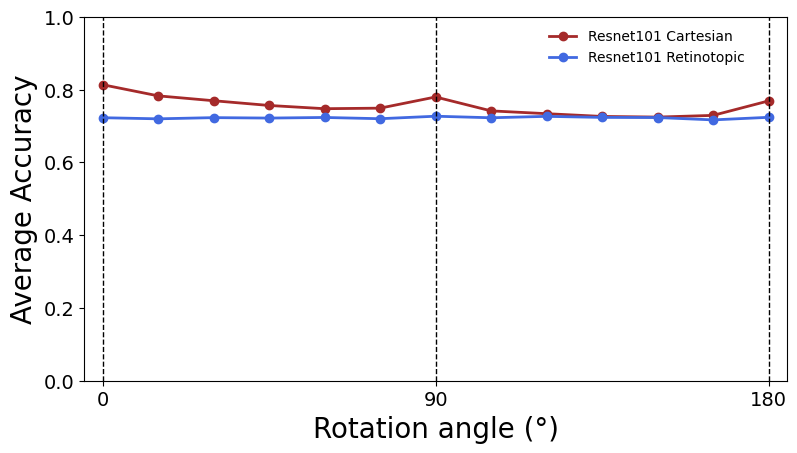

In [8]:
print(f'{filename=}')
angles = np.arange(-180, 181, 15)
verbose = False

if os.path.isfile(filename):
    df_angle = pd.read_json(filename)
    
    
fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))


colors = ['brown', 'royalblue',  'orange', 'lightsteelblue']

labels = {'cached_data/2024-01-16_resnet101_do_polar=False.pt':'Resnet101 Cartesian', 'cached_data/2024-01-16_resnet101_do_polar=True.pt':'Resnet101 Retinotopic'}

for i, model_name in enumerate(['cached_data/2024-01-16_resnet101_do_polar=False.pt', 'cached_data/2024-01-16_resnet101_do_polar=True.pt']):
    if 'vgg' in model_name:
        ax = df_angle[(df_angle['model']==model_name)].plot(x="var", y="mean_prediction", color=colors[i],
                                                         marker='x', lw=2, label=labels[model_name], ax=ax)
    else:
        ax = df_angle[(df_angle['model']==model_name)].plot(x="var", y="mean_prediction", color=colors[i],
                                                         marker='o', lw=2, label=labels[model_name], ax=ax)
    print(f'Mean for {model_name}', np.mean(df_angle[(df_angle['model']==model_name)]['mean_prediction']))
    print(f'Std for {model_name}', np.std(df_angle[(df_angle['model']==model_name)]['mean_prediction']))


#ax.hlines(xmin=-185, xmax=185, y=1/2, ls='--', ec='gray')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_xlim(-5, 185)
ax.set_ylim(0, 1)


ax.axvline(x=0, c='k', ls='--', lw=1)
plt.axvline(x=90, c='k', ls='--', lw=1)
plt.axvline(x=180, c='k', ls='--', lw=1)
ax.set_xticks([0, 90, 180])
#ax.set_yscale("logit", use_overline=True) #one_half="1/2", 
#ax.set_yticks([.7, .75, .8])
ax.set_ylabel('Average Accuracy', font=font)
ax.set_xlabel('Rotation angle (°)', font=font)
plt.legend(bbox_to_anchor=(0.8, 1), loc='upper center', fontsize=10, edgecolor='none')
plt.tight_layout()
# plt.xticks(font=font)
# plt.yticks(font=font);


filename='cached_data/2024-03-11_results_rotate_test_do_rottrain=False.json'
Mean for resnet101_False nan
Std for resnet101_False nan
Mean for resnet101_True nan
Std for resnet101_True nan


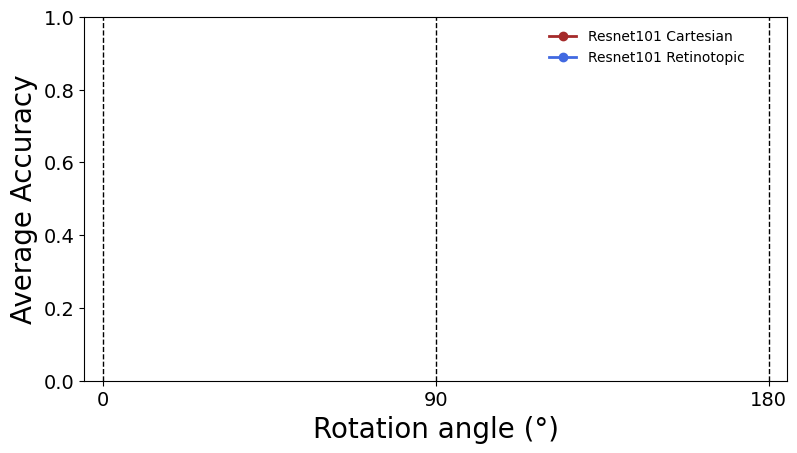

In [9]:
# datetag = strftime("%Y-%m-%d", gmtime())
datetag = '2023-04-11'
datetag = '2023-06-08'


#filename = f'cached_data/{datetag}_results_10k_rot_eval.json'
filename = f'cached_data/2024-03-11_results_rotate_test_do_rottrain=False.json'

print(f'{filename=}')
angles = np.arange(-180, 181, 15)
verbose = False

if os.path.isfile(filename):
    df_angle = pd.read_json(filename)
    
    
fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))


colors = ['brown', 'royalblue',  'orange', 'lightsteelblue']

labels = {'resnet101_False':'Resnet101 Cartesian', 'resnet101_True':'Resnet101 Retinotopic'}

for i, model_name in enumerate(['resnet101_False', 'resnet101_True']):
    if 'vgg' in model_name:
        ax = df_angle[(df_angle['model']==model_name)].plot(x="var", y="mean_prediction", color=colors[i],
                                                         marker='x', lw=2, label=labels[model_name], ax=ax)
    else:
        ax = df_angle[(df_angle['model']==model_name)].plot(x="var", y="mean_prediction", color=colors[i],
                                                         marker='o', lw=2, label=labels[model_name], ax=ax)
    print(f'Mean for {model_name}', np.mean(df_angle[(df_angle['model']==model_name)]['mean_prediction']))
    print(f'Std for {model_name}', np.std(df_angle[(df_angle['model']==model_name)]['mean_prediction']))


#ax.hlines(xmin=-185, xmax=185, y=1/2, ls='--', ec='gray')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_xlim(-5, 185)
ax.set_ylim(0, 1)


ax.axvline(x=0, c='k', ls='--', lw=1)
plt.axvline(x=90, c='k', ls='--', lw=1)
plt.axvline(x=180, c='k', ls='--', lw=1)
ax.set_xticks([0, 90, 180])
#ax.set_yscale("logit", use_overline=True) #one_half="1/2", 
#ax.set_yticks([.7, .75, .8])
ax.set_ylabel('Average Accuracy', font=font)
ax.set_xlabel('Rotation angle (°)', font=font)
plt.legend(bbox_to_anchor=(0.8, 1), loc='upper center', fontsize=10, edgecolor='none')
plt.tight_layout()
# plt.xticks(font=font)
# plt.yticks(font=font);


In [10]:
df

NameError: name 'df' is not defined